**## Dataset**

In this project, i use two publicly available fake news datasets.

**1. ISOT Fake News Dataset (University of Victoria, ISOT Lab)**
This dataset contains two separate CSV files: Fake.csv and True.csv.
Each row represents a news article collected from real-world sources between 2016–2018.
After merging, the combined dataset includes approximately **44.898** news articles, each labeled as Fake (0) or Real (1).

Features:

Title: The headline of the news article.
Text: The full content/body of the news article.
Subject: Category of the news (e.g., world news, politics, etc.).
Date: Publication date.
Label: Binary (0 = fake, 1 = real).

**2. WELFake Dataset (Kaggle, 2021)**
This dataset consists of approximately **72.134** news articles labeled as Fake or Real.
It was created by combining four publicly available datasets (Kaggle Fake News, McIntire, Reuters, BuzzFeed).
It provides a larger and more diverse corpus for cross-dataset evaluation.

Features:

Title: News headline.
Text: News content.
Label: Binary (0 = fake, 1 = real).

Both datasets are text-based and will be preprocessed by removing punctuation, URLs, numbers, and converting text to lowercase before feature extraction and modeling.

In [ ]:
import os, re, glob
import pandas as pd
import numpy as np
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

ISOT_TRUE_PATH = Path("/content/drive/MyDrive/Colab Notebooks/nlp-project/True.csv")
ISOT_FAKE_PATH = Path("/content/drive/MyDrive/Colab Notebooks/nlp-project/Fake.csv")
WELFAKE_PATH   = Path("/content/drive/MyDrive/Colab Notebooks/nlp-project/WELFake_Dataset.csv")

def exists(p: Path) -> bool:
    try:
        return p is not None and p.exists()
    except Exception:
        return False

if not (exists(ISOT_TRUE_PATH) and exists(ISOT_FAKE_PATH)):
    hits_true = glob.glob("/content/drive/**/*True*.csv", recursive=True)
    hits_fake = glob.glob("/content/drive/**/*Fake*.csv", recursive=True)
    ISOT_TRUE_PATH = Path(hits_true[0]) if hits_true else None
    ISOT_FAKE_PATH = Path(hits_fake[0]) if hits_fake else None

if not exists(WELFAKE_PATH):
    hits_welf = glob.glob("/content/drive/**/*WELFake*.csv", recursive=True)
    WELFAKE_PATH = Path(hits_welf[0]) if hits_welf else None

print("True.csv :", ISOT_TRUE_PATH)
print("Fake.csv :", ISOT_FAKE_PATH)
print("WELFake  :", WELFAKE_PATH)

def _coalesce_col(df, choices):
    for c in choices:
        if c in df.columns:
            return c
    lower_map = {c.lower(): c for c in df.columns}
    for c in choices:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True.csv : /content/drive/MyDrive/Colab Notebooks/nlp-project/True.csv
Fake.csv : /content/drive/MyDrive/Colab Notebooks/nlp-project/Fake.csv
WELFake  : /content/drive/MyDrive/Colab Notebooks/nlp-project/WELFake_Dataset.csv


In [ ]:


def load_isot(true_path: Path, fake_path: Path) -> pd.DataFrame:
    assert exists(true_path) and exists(fake_path), "ISOT yolları bulunamadı."
    df_true = pd.read_csv(true_path, encoding="utf-8", engine="python", on_bad_lines="skip")
    df_fake = pd.read_csv(fake_path, encoding="utf-8", engine="python", on_bad_lines="skip")

    def normalize(df, lbl):
        tcol = _coalesce_col(df, ["title"])
        xcol = _coalesce_col(df, ["text","content","article","body","news"])
        df["title"] = df[tcol].astype(str).fillna("") if tcol else ""
        df["text"]  = df[xcol].astype(str).fillna("") if xcol else ""
        df["combined"] = (df["title"] + " " + df["text"]).str.strip()
        # Şema: 1=Real, 0=Fake
        df["label"] = 1 if lbl=="real" else 0
        return df[["title","text","combined","label"]]

    df_true = normalize(df_true, "real")
    df_fake = normalize(df_fake, "fake")
    out = pd.concat([df_true, df_fake], ignore_index=True)
    out["source_dataset"] = "ISOT"
    return out[["source_dataset","label","title","text","combined"]]

def load_welfake(path: Path) -> pd.DataFrame:
    assert exists(path), "WELFake yolu bulunamadı."
    df = pd.read_csv(path, encoding="utf-8", engine="python", on_bad_lines="skip")

    label_col = _coalesce_col(df, ["label","labels","class","target"])
    text_col  = _coalesce_col(df, ["text","content","article","news","body"])
    title_col = _coalesce_col(df, ["title","headline"])
    assert label_col and text_col, f"label/text kolonları yok. Var olanlar: {list(df.columns)[:12]}"

    def _map_label(v):
        s = str(v).strip().lower()
        if s in {"real","1","true","t"}:  return 1
        if s in {"fake","0","false","f"}: return 0
        try: return int(s)
        except: return np.nan

    df["label"] = df[label_col].apply(_map_label).astype("Int64")
    if df["label"].isna().any():
        med = int(df["label"].dropna().median())
        df["label"] = df["label"].fillna(med).astype(int)

    df["title"]    = df[title_col].astype(str) if title_col else ""
    df["text"]     = df[text_col].astype(str).fillna("")
    df["combined"] = (df["title"] + " " + df["text"]).str.strip()
    df["source_dataset"] = "WELFake"
    return df[["source_dataset","label","title","text","combined"]]

In [ ]:

frames = []
if exists(ISOT_TRUE_PATH) and exists(ISOT_FAKE_PATH):
    try:
        frames.append(load_isot(ISOT_TRUE_PATH, ISOT_FAKE_PATH))
        print("OK: ISOT yüklendi.")
    except Exception as e:
        print("HATA: ISOT:", e)

if exists(WELFAKE_PATH):
    try:
        frames.append(load_welfake(WELFAKE_PATH))
        print("OK: WELFake yüklendi.")
    except Exception as e:
        print("HATA: WELFake:", e)

if not frames:
    print("\n!!! Dosyalar Drive'da bulunamadı. Şimdi bilgisayarından seçip yükleyebilirsin...")
    try:
        from google.colab import files
        uploaded = files.upload()
        up_names = list(uploaded.keys())
        for n in up_names:
            path = Path("/content")/n
            if "true" in n.lower(): ISOT_TRUE_PATH = path
            if "fake" in n.lower() and "wel" not in n.lower(): ISOT_FAKE_PATH = path
            if "welfake" in n.lower(): WELFAKE_PATH = path
        if exists(ISOT_TRUE_PATH) and exists(ISOT_FAKE_PATH):
            frames.append(load_isot(ISOT_TRUE_PATH, ISOT_FAKE_PATH))
            print("OK: ISOT yüklendi.")
        if exists(WELFAKE_PATH):
            frames.append(load_welfake(WELFAKE_PATH))
            print("OK: WELFake yüklendi.")
    except Exception as e:
        print("Upload aşamasında sorun:", e)

assert frames, "Hiç veri bulunamadı. dosyaları kontrol et."

df_all = pd.concat(frames, ignore_index=True)
df_all.dropna(subset=["combined"], inplace=True)
df_all.drop_duplicates(subset=["combined"], inplace=True)

OK: ISOT yüklendi.
OK: WELFake yüklendi.


In [ ]:
def dataset_report(df, name: str):
    print(f"\n=== DATASET: {name} ===")
    print("Rows:", len(df))
    print(df['label'].value_counts().rename({0:'Fake', 1:'Real'}))
    print("\nMissing values:")
    print(df[['title','text','combined']].isna().sum())
    dup_combined = df['combined'].duplicated().sum()
    print(f"\nDuplicate combined texts: {dup_combined}")
    lengths = df['combined'].fillna('').astype(str).map(len)
    words = df['combined'].fillna('').astype(str).map(lambda s: len(s.split()))
    print("\nLength stats (chars):", lengths.describe().to_dict())
    print("Length stats (words):", words.describe().to_dict())

for name in df_all['source_dataset'].unique():
    dataset_report(df_all[df_all['source_dataset']==name], name)



=== DATASET: ISOT ===
Rows: 39103
label
Real    21196
Fake    17907
Name: count, dtype: int64

Missing values:
title       0
text        0
combined    0
dtype: int64

Duplicate combined texts: 0

Length stats (chars): {'count': 39103.0, 'mean': 2504.6169859090096, 'std': 1943.5467356949302, 'min': 29.0, '25%': 1347.0, '50%': 2287.0, '75%': 3162.0, 'max': 51893.0}
Length stats (words): {'count': 39103.0, 'mean': 410.4489681098637, 'std': 315.09151581703657, 'min': 2.0, '25%': 220.0, '50%': 378.0, '75%': 521.0, 'max': 8148.0}

=== DATASET: WELFake ===
Rows: 24586
label
Fake    13594
Real    10992
Name: count, dtype: int64

Missing values:
title       0
text        0
combined    0
dtype: int64

Duplicate combined texts: 0

Length stats (chars): {'count': 24586.0, 'mean': 4685.490807776783, 'std': 4882.980899005612, 'min': 5.0, '25%': 1777.0, '50%': 3613.0, '75%': 6406.0, 'max': 115448.0}
Length stats (words): {'count': 24586.0, 'mean': 780.7184169852761, 'std': 827.3658405999178, 'min': 

**## Remove null values**

In [ ]:
import re

print("Before cleaning:", df_all.shape)
df_all = df_all.dropna(subset=['combined'])           # remove nulls
df_all = df_all.drop_duplicates(subset=['combined'])  # remove duplicates
print("After removing nulls & duplicates:", df_all.shape)

# text cleaning
URL_RE  = re.compile(r'https?://\S+|www\.\S+')
HTML_RE = re.compile(r'<.*?>')

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = URL_RE.sub(" ", text)
    t = HTML_RE.sub(" ", t)
    t = t.replace("\n", " ").replace("\t", " ")
    t = re.sub(r"\s+", " ", t).strip()
    return t

df_all['clean_text'] = df_all['combined'].apply(clean_text)
df_all[['source_dataset','label','clean_text']].head()


Before cleaning: (63689, 5)
After removing nulls & duplicates: (63689, 5)


,source_dataset,label,clean_text
0,ISOT,1,"As U.S. budget fight looms, Republicans flip t..."
1,ISOT,1,U.S. military to accept transgender recruits o...
2,ISOT,1,Senior U.S. Republican senator: 'Let Mr. Muell...
3,ISOT,1,FBI Russia probe helped by Australian diplomat...
4,ISOT,1,Trump wants Postal Service to charge 'much mor...


**## Preprocess the data**


In [ ]:
import re

def preprocess(text_series):
    # URL ve HTML temizleme
    text_series = text_series.str.replace("(<br/>)", " ", regex=True)
    text_series = text_series.str.replace("(<a).*(>).*(</a>)", " ", regex=True)
    text_series = text_series.str.replace("(&amp)", "&", regex=True)
    text_series = text_series.str.replace("(&gt)", ">", regex=True)
    text_series = text_series.str.replace("(&lt)", "<", regex=True)
    text_series = text_series.str.replace("(\xa0)", " ", regex=True)
    text_series = text_series.str.replace(r"http\S+", " ", regex=True)
    text_series = text_series.str.replace(r"<.*?>", " ", regex=True)
    text_series = text_series.str.replace(r"\s+", " ", regex=True)
    return text_series.str.strip()

df_all['clean_text'] = preprocess(df_all['clean_text'])

df_all['word_count']  = df_all['clean_text'].apply(lambda x: len(str(x).split()))
df_all['char_count']  = df_all['clean_text'].apply(lambda x: len(str(x)))
df_all['upper_ratio'] = df_all['clean_text'].apply(lambda x: sum(1 for ch in str(x) if ch.isupper()) / len(str(x)) if len(str(x)) > 0 else 0)

df_all[['source_dataset','label','word_count','char_count','upper_ratio']].head()


,source_dataset,label,word_count,char_count,upper_ratio
0,ISOT,1,759,4720,0.033686
1,ISOT,1,633,4141,0.029703
2,ISOT,1,467,2841,0.043647
3,ISOT,1,385,2520,0.046825
4,ISOT,1,863,5262,0.038769


**## Check sample Fake and Real news examples**





In [ ]:
print("=== Real News (label == 1) ===")
real_samples = df_all.loc[df_all.label == 1, ['clean_text']].sample(5, random_state=42).values
for r in real_samples:
    print(r[0][:400], "\n---\n")


print("\n=== Fake News (label == 0) ===")
fake_samples = df_all.loc[df_all.label == 0, ['clean_text']].sample(5, random_state=42).values
for f in fake_samples:
    print(f[0][:400], "\n---\n")


=== Real News (label == 1) ===
News: Major Headache: The Blue Angels Got Trapped Inside A Costco, And No One Knows How To Get Them Back Outside Email Well, this isn’t good. Most people think of Costco as the place that sells bulk quantities of pretty much everything. But the warehouse superstore is now making headlines for a very different reason, and it could serve to tarnish their brand: The Blue Angels accidentally flew into 
---

U.S. aid chief says no sign Yemen port blockade easing to allow aid in WASHINGTON (Reuters) - There are no signs that a blockade of Yemen s ports by a Saudi-led military coalition has eased to allow aid to reach communities increasingly at risk of starvation, the head of the U.S. government s aid agency said on Tuesday. USAID administrator Mark Green called on the Saudi-led military coalition to o 
---

Exclusive: Immigration judges headed to 12 U.S. cities to speed deportations WASHINGTON (Reuters) - The U.S. Justice Department is developing plans to temp

**## Distribution of text-based feature scores**


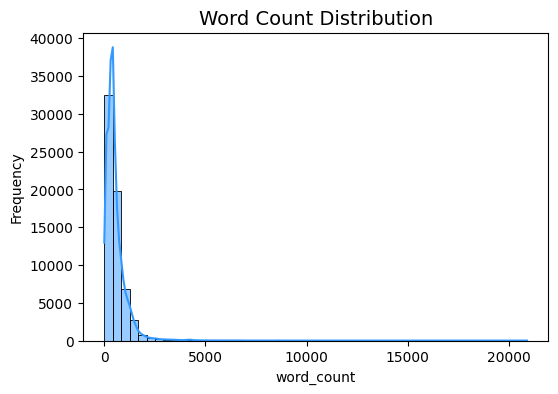

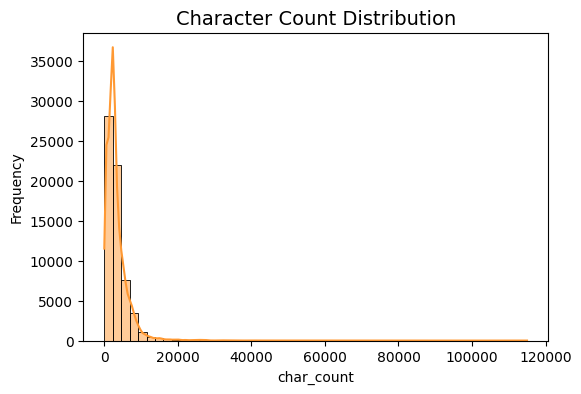

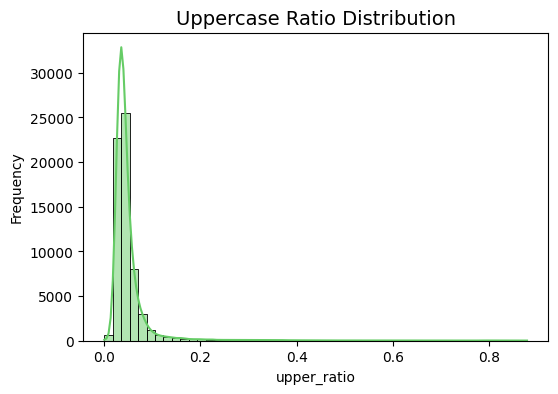

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['word_count', 'char_count', 'upper_ratio']
titles = ['Word Count Distribution', 'Character Count Distribution', 'Uppercase Ratio Distribution']
colors = ['#3399ff', '#ff9933', '#66cc66']

for feature, title, color in zip(features, titles, colors):
    plt.figure(figsize=(6,4))
    sns.histplot(data=df_all, x=feature, bins=50, color=color, kde=True)
    plt.title(title, fontsize=14)
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()


**## Distribution of news labels**


/tmp/ipython-input-1891154884.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_all, palette='viridis')


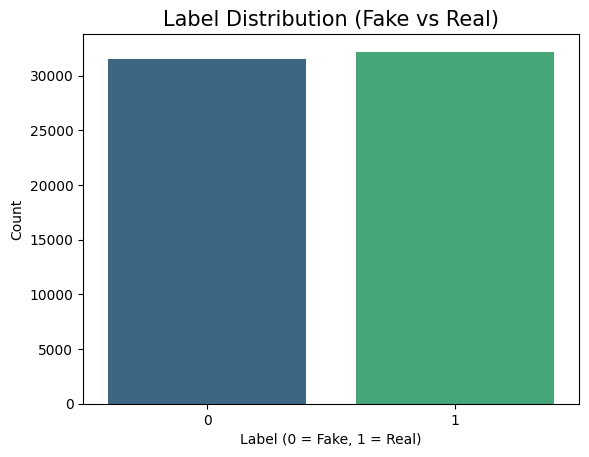

Label distribution (%):
label
1    50.53934
0    49.46066
Name: proportion, dtype: float64


In [ ]:
sns.countplot(x='label', data=df_all, palette='viridis')
plt.title('Label Distribution (Fake vs Real)', size=15)
plt.xlabel('Label (0 = Fake, 1 = Real)')
plt.ylabel('Count')
plt.show()

label_counts = df_all['label'].value_counts(normalize=True) * 100
print("Label distribution (%):")
print(label_counts)


**## Distribution by Source Dataset and Label**

---




/tmp/ipython-input-1873827387.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='source_dataset', data=df_all, palette='viridis')


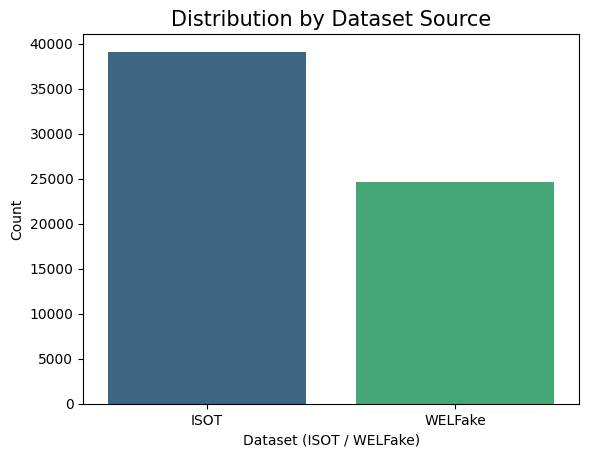

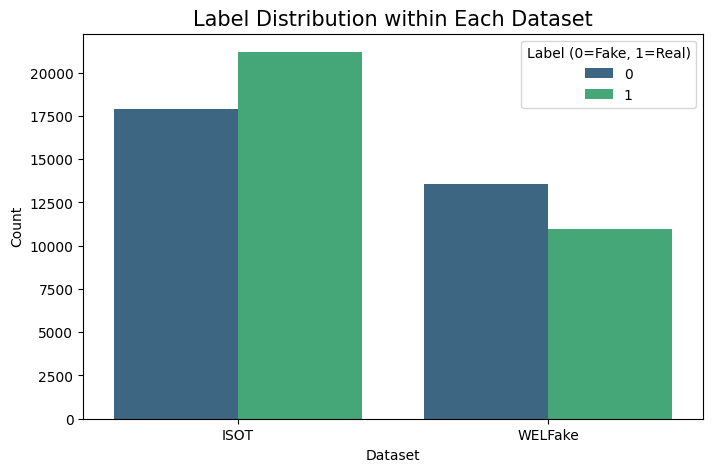

In [ ]:
# Distribution by dataset source (ISOT vs WELFake)
sns.countplot(x='source_dataset', data=df_all, palette='viridis')
plt.title('Distribution by Dataset Source', size=15)
plt.xlabel('Dataset (ISOT / WELFake)')
plt.ylabel('Count')
plt.show()

# Distribution by label within datasets
plt.figure(figsize=(8,5))
sns.countplot(x='source_dataset', hue='label', data=df_all, palette='viridis')
plt.title('Label Distribution within Each Dataset', size=15)
plt.xlabel('Dataset')
plt.ylabel('Count')
plt.legend(title='Label (0=Fake, 1=Real)')
plt.show()


**## Distribution of Classes (Fake vs Real within Source)**


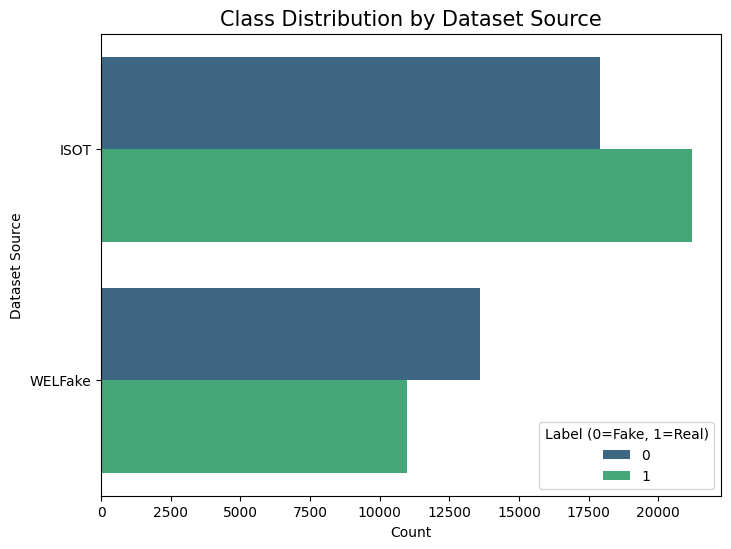

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(y='source_dataset', hue='label', data=df_all, palette='viridis')
plt.title('Class Distribution by Dataset Source', size=15)
plt.xlabel('Count')
plt.ylabel('Dataset Source')
plt.legend(title='Label (0=Fake, 1=Real)')
plt.show()


## Unigrams, Bigrams and Trigrams

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

sns.set(style="whitegrid")



In [ ]:
def get_top_ngrams(
    corpus,
    ngram_range,
    stop_words=None,
    topn=20,
    min_df=2,
    max_features=100_000,
    token_pattern=r'(?u)\b\w+\b'
):
    vec = CountVectorizer(
        ngram_range=ngram_range,
        stop_words=stop_words,
        lowercase=True,
        min_df=min_df,
        max_features=max_features,
        token_pattern=token_pattern
    )
    X = vec.fit_transform(corpus)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    terms = vec.get_feature_names_out()

    df = pd.DataFrame({"Word": terms, "Freq": freqs})
    df = df.sort_values("Freq", ascending=False).head(topn)
    df = df.sort_values("Freq", ascending=True).reset_index(drop=True)
    return df



In [ ]:
corpus = df_all['clean_text'].astype(str).tolist()
TOPN = 20


In [ ]:
unigrams  = get_top_ngrams(corpus, (1,1), stop_words=None, topn=TOPN)
bigrams   = get_top_ngrams(corpus, (2,2), stop_words=None, topn=TOPN)
trigrams  = get_top_ngrams(corpus, (3,3), stop_words=None, topn=TOPN, min_df=3)


In [ ]:
unigrams_st = get_top_ngrams(corpus, (1,1), stop_words='english', topn=TOPN)
bigrams_st  = get_top_ngrams(corpus, (2,2), stop_words='english', topn=TOPN)
trigrams_st = get_top_ngrams(corpus, (3,3), stop_words='english', topn=TOPN, min_df=3)


In [ ]:
def plot_barh(df, title, color):
    plt.figure(figsize=(8,10))
    sns.barplot(x='Freq', y='Word', data=df, color=color)
    plt.title(title, fontsize=15)
    plt.xlabel('Frequency')
    plt.ylabel('Term')
    plt.tight_layout()
    plt.show()



**##Unigram**

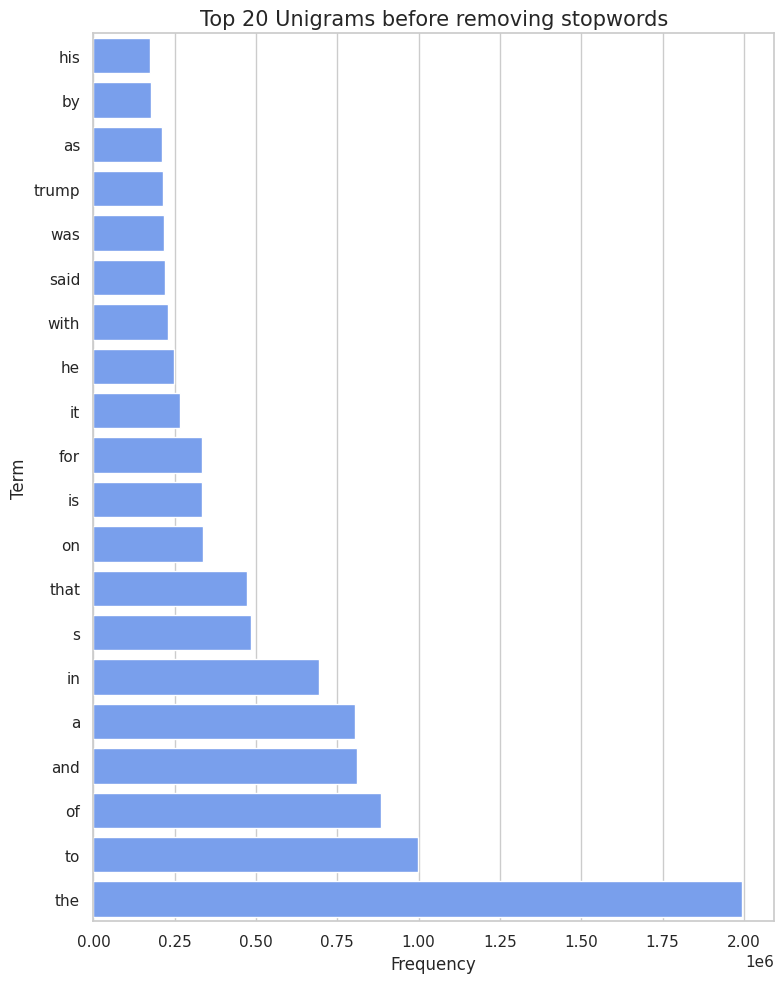

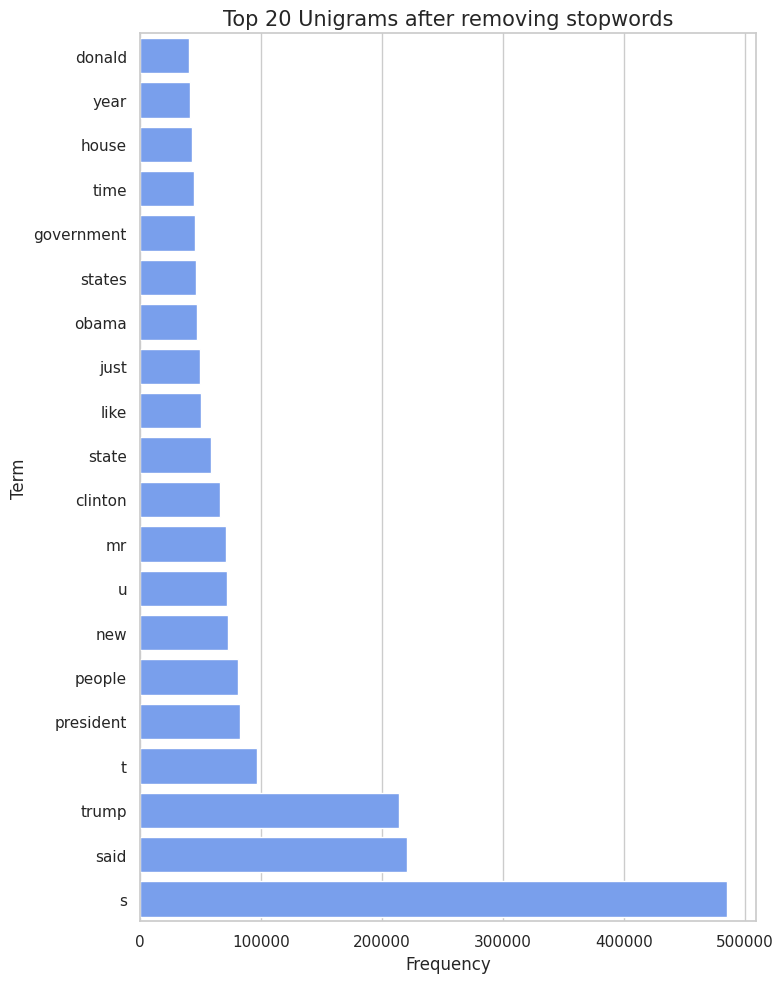

In [ ]:
plot_barh(unigrams,    'Top 20 Unigrams before removing stopwords', '#6699ff')
plot_barh(unigrams_st, 'Top 20 Unigrams after removing stopwords',  '#6699ff')


**## Bigrams**


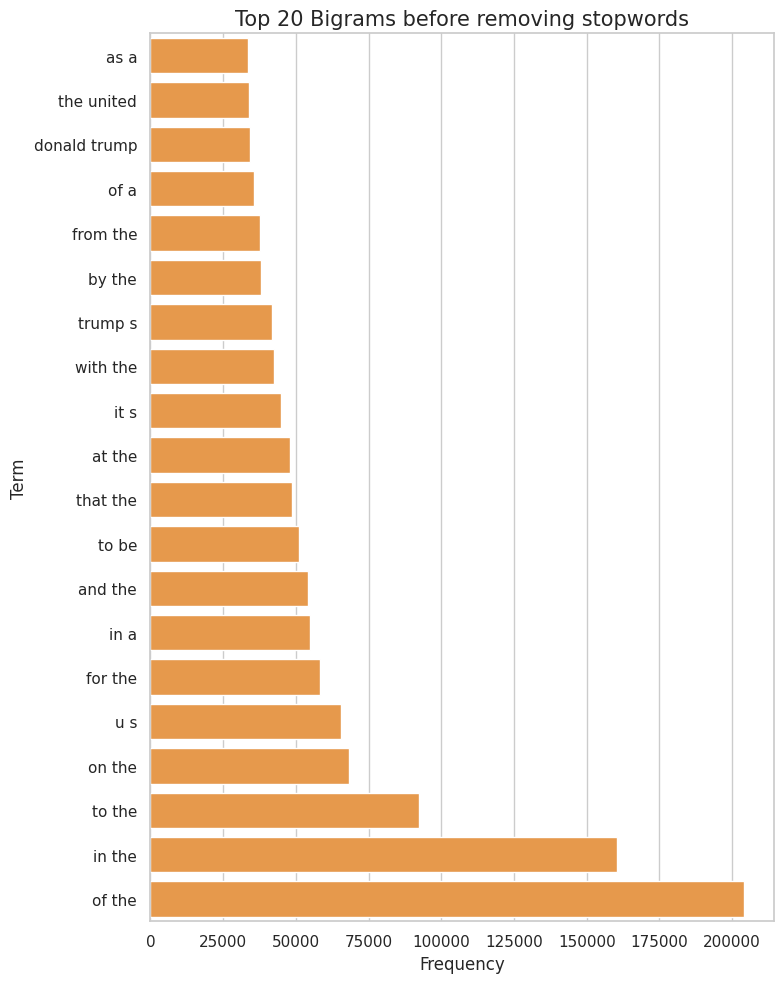

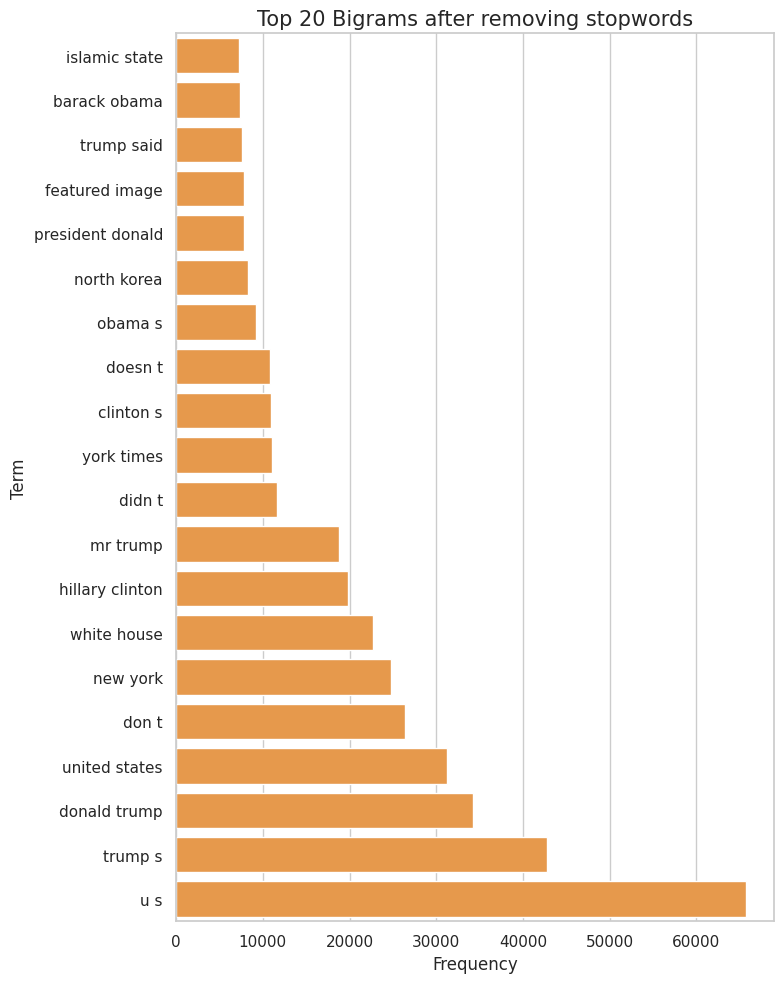

In [ ]:
plot_barh(bigrams,     'Top 20 Bigrams before removing stopwords',  '#ff9933')
plot_barh(bigrams_st,  'Top 20 Bigrams after removing stopwords',   '#ff9933')


**## Trigrams**




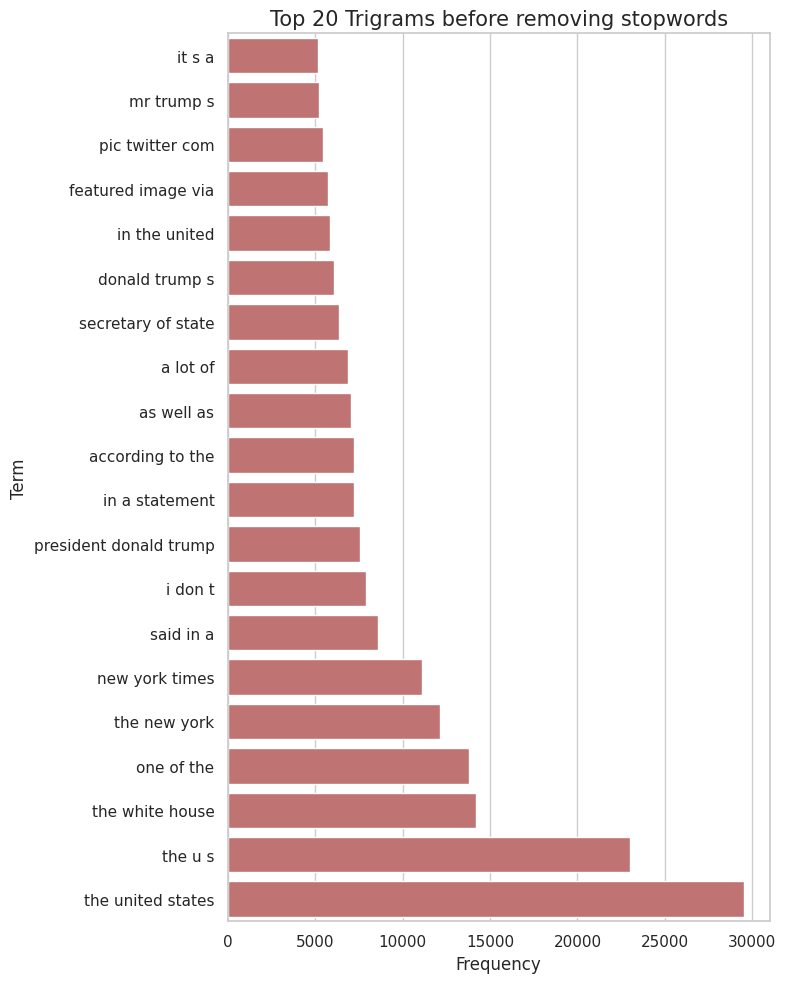

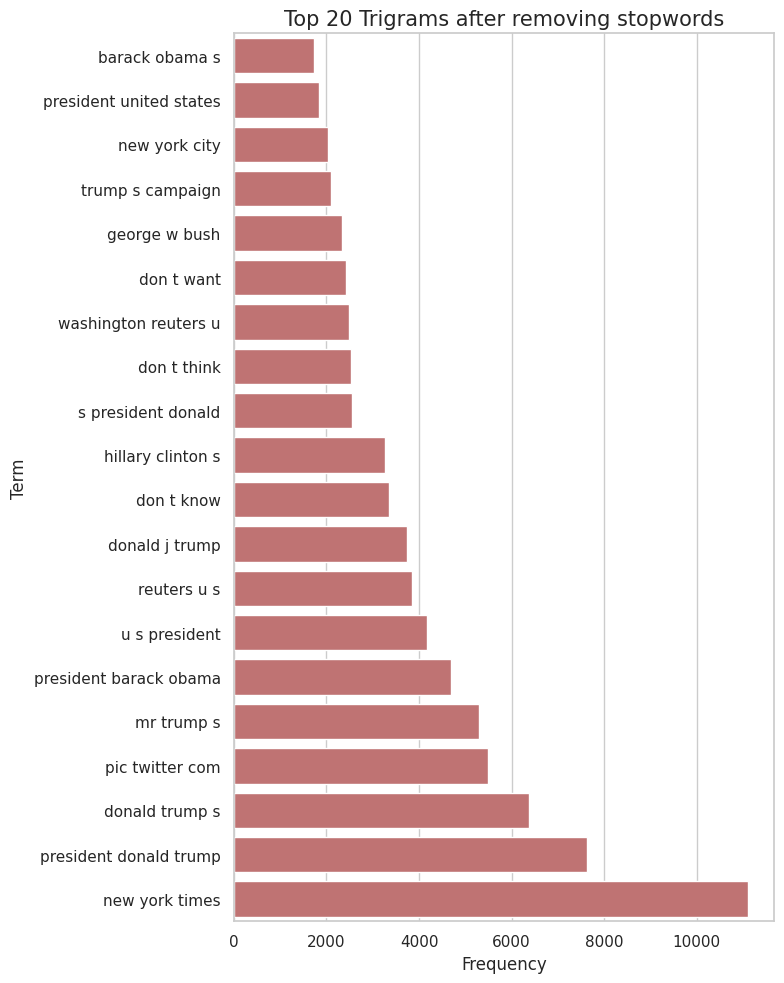

In [ ]:
plot_barh(trigrams,    'Top 20 Trigrams before removing stopwords', '#cc6666')
plot_barh(trigrams_st, 'Top 20 Trigrams after removing stopwords',  '#cc6666')


**## Part-of-Speech Tagging (POS)**

In [ ]:
try:
    from textblob import TextBlob
except ImportError:
    !pip -q install textblob
    from textblob import TextBlob

import nltk, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
sns.set(style="whitegrid")

In [ ]:
!pip -q install -U textblob nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 42.8 MB/s eta 0:00:00


In [ ]:
import nltk

for pkg in [
    "punkt",
    "punkt_tab",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "brown", "wordnet", "omw-1.4"
]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

import textblob.download_corpora as tb_corpora
tb_corpora.download_all()




[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


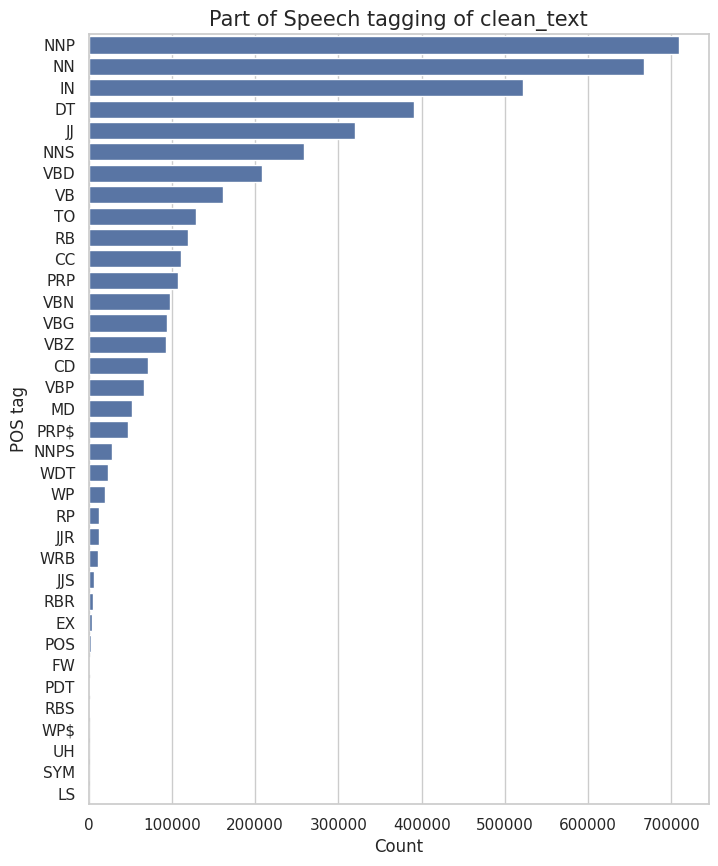

In [ ]:
from textblob import TextBlob
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

sns.set(style="whitegrid")

text_blob_input = " ".join(df_all['clean_text'].astype(str).head(10_000))
blob = TextBlob(text_blob_input)

pos_df = pd.DataFrame(blob.tags, columns=['word', 'pos'])
top_pos = pos_df['pos'].value_counts()

plt.figure(figsize=(8, 10))
sns.barplot(y=top_pos.index, x=top_pos.values)
plt.title('Part of Speech tagging of clean_text', size=15)
plt.xlabel('Count')
plt.ylabel('POS tag')
plt.show()


**Sentiment Polarity vs Source Dataset**



In [ ]:
from textblob import TextBlob

# Her haber için duygu skoru
df_all['Polarity'] = df_all['clean_text'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

df_all['text_len'] = df_all['clean_text'].astype(str).apply(lambda x: len(x.split()))


/tmp/ipython-input-1826650365.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='source_dataset', y='Polarity', width=0.5, palette='viridis', data=df_all)


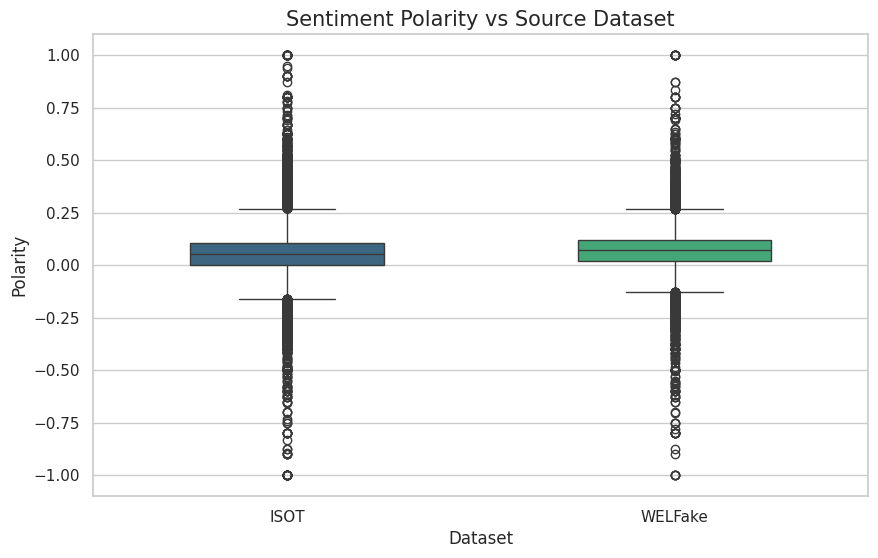

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='source_dataset', y='Polarity', width=0.5, palette='viridis', data=df_all)
plt.title('Sentiment Polarity vs Source Dataset', size=15)
plt.xlabel('Dataset')
plt.ylabel('Polarity')
plt.show()


**Sentiment Polarity vs Label**




/tmp/ipython-input-1666862595.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='Polarity', width=0.5, palette='mako', data=df_all)


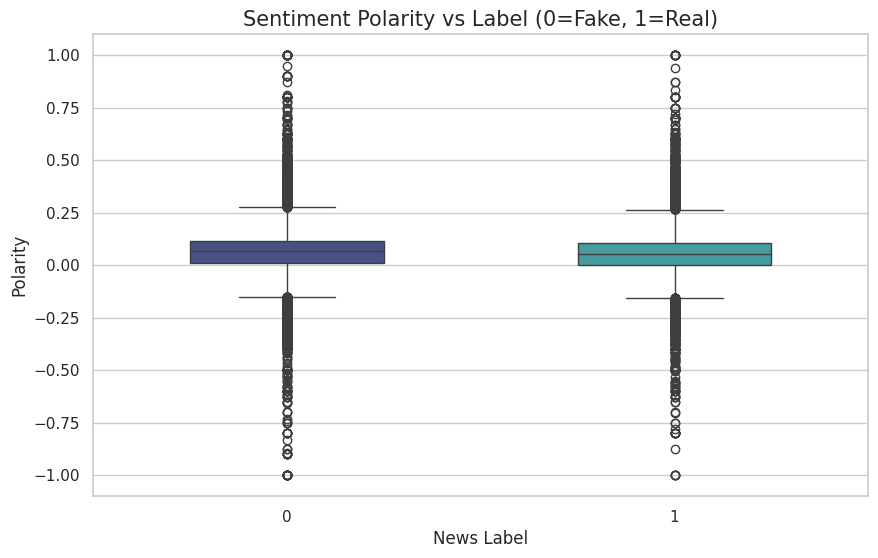

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='Polarity', width=0.5, palette='mako', data=df_all)
plt.title('Sentiment Polarity vs Label (0=Fake, 1=Real)', size=15)
plt.xlabel('News Label')
plt.ylabel('Polarity')
plt.show()


Text Length vs Label



/tmp/ipython-input-3174395170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='text_len', width=0.5, palette='cubehelix', data=df_all)


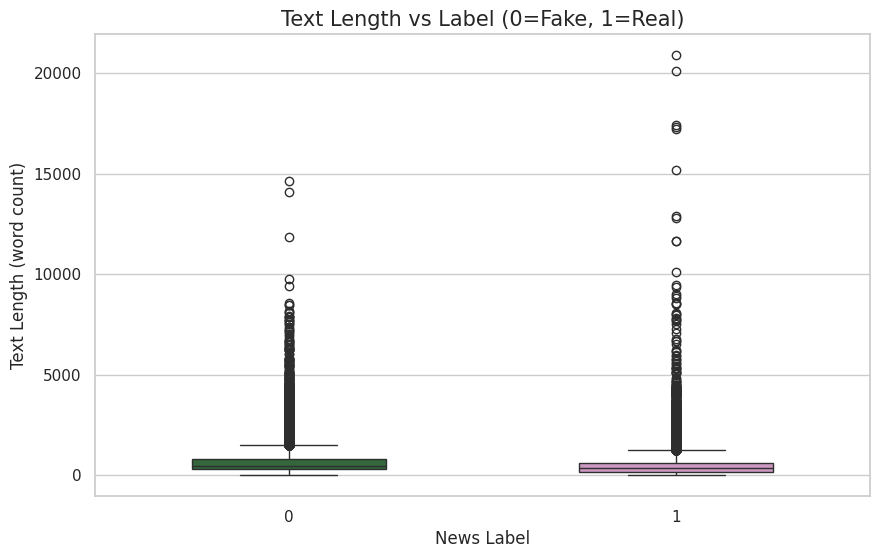

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='text_len', width=0.5, palette='cubehelix', data=df_all)
plt.title('Text Length vs Label (0=Fake, 1=Real)', size=15)
plt.xlabel('News Label')
plt.ylabel('Text Length (word count)')
plt.show()


Distribution of Sentiment Polarity of News based on Label

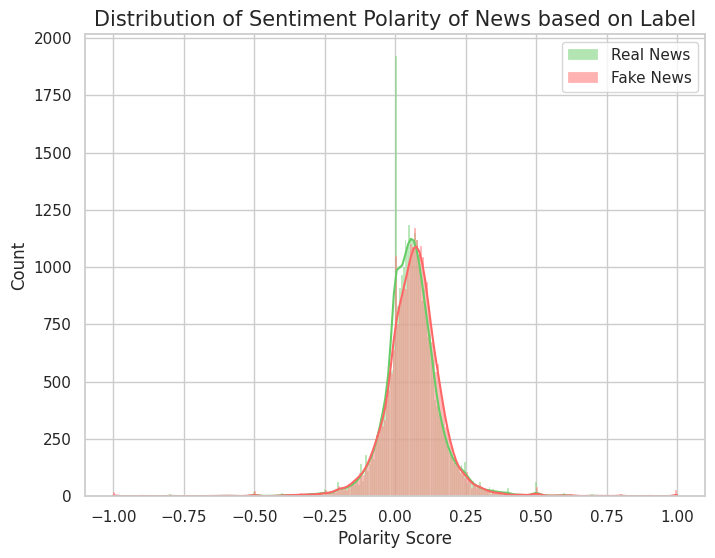

In [ ]:
real_news = df_all.loc[df_all['label'] == 1, 'Polarity']
fake_news = df_all.loc[df_all['label'] == 0, 'Polarity']

plt.figure(figsize=(8, 6))
sns.histplot(x=real_news, color="#66cc66", label='Real News', kde=True)
sns.histplot(x=fake_news, color="#ff6666", label='Fake News', kde=True)
plt.title('Distribution of Sentiment Polarity of News based on Label', size=15)
plt.xlabel('Polarity Score')
plt.legend()
plt.show()


Distribution of Polarity by Dataset Source (ISOT vs WELFake)

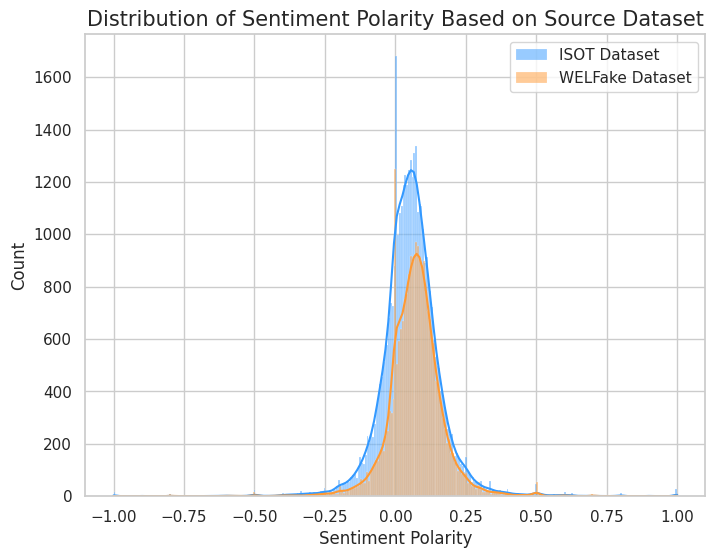

In [ ]:
ISOT_polarity = df_all.loc[df_all['source_dataset'] == 'ISOT', 'Polarity']
WEL_polarity  = df_all.loc[df_all['source_dataset'] == 'WELFake', 'Polarity']

plt.figure(figsize=(8, 6))
sns.histplot(x=ISOT_polarity, color="#3399ff", label='ISOT Dataset', kde=True)
sns.histplot(x=WEL_polarity, color="#ff9933", label='WELFake Dataset', kde=True)
plt.title('Distribution of Sentiment Polarity Based on Source Dataset', size=15)
plt.xlabel('Sentiment Polarity')
plt.legend()
plt.show()


Distribution of Text Length Based on News Label

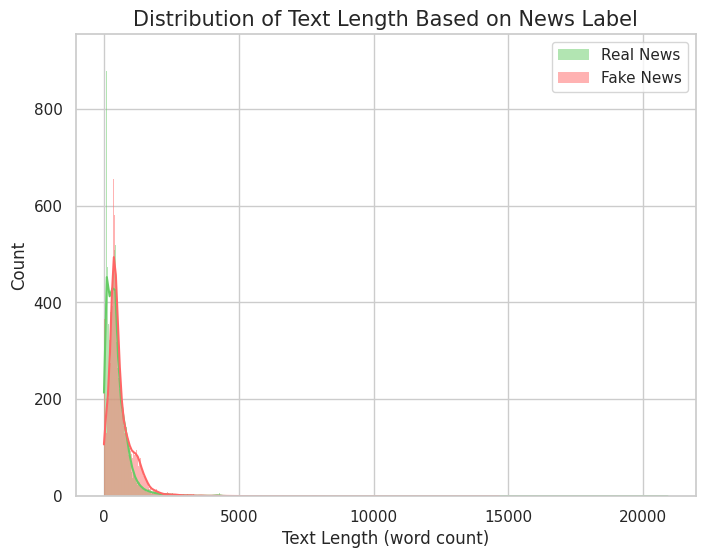

In [ ]:
real_len = df_all.loc[df_all['label'] == 1, 'text_len']
fake_len = df_all.loc[df_all['label'] == 0, 'text_len']

plt.figure(figsize=(8, 6))
sns.histplot(x=real_len, color="#66cc66", kde=True, label='Real News', binwidth=10)
sns.histplot(x=fake_len, color="#ff6666", kde=True, label='Fake News', binwidth=10)
plt.title('Distribution of Text Length Based on News Label', size=15)
plt.xlabel('Text Length (word count)')
plt.legend()
plt.show()


2D Density Jointplot of News Label and Sentiment Polarity

<Figure size 800x800 with 0 Axes>

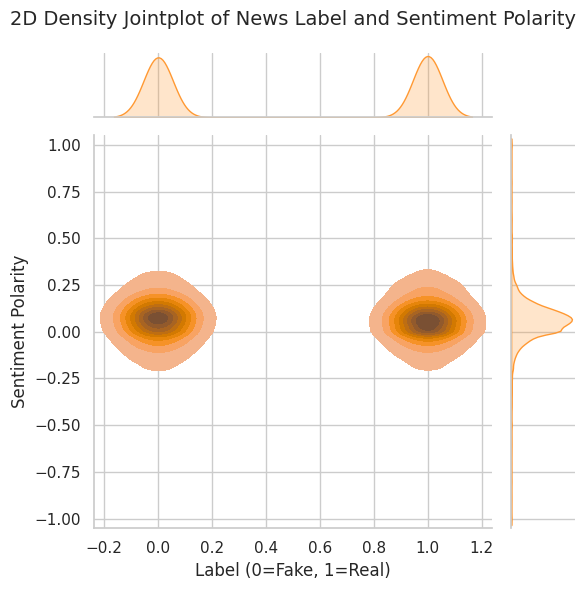

In [ ]:
plt.figure(figsize=(8, 8))
g = sns.jointplot(x='label', y='Polarity', kind='kde', fill=True, color='#ff9933', data=df_all)
g.plot_joint(sns.kdeplot, fill=True, color='#ff9933', zorder=0, levels=6)
plt.suptitle('2D Density Jointplot of News Label and Sentiment Polarity', size=14)
plt.xlabel('Label (0=Fake, 1=Real)')
plt.ylabel('Sentiment Polarity')
plt.tight_layout()
plt.show()


2D Density Jointplot of Text Length and Sentiment Polarity

<Figure size 1000x800 with 0 Axes>

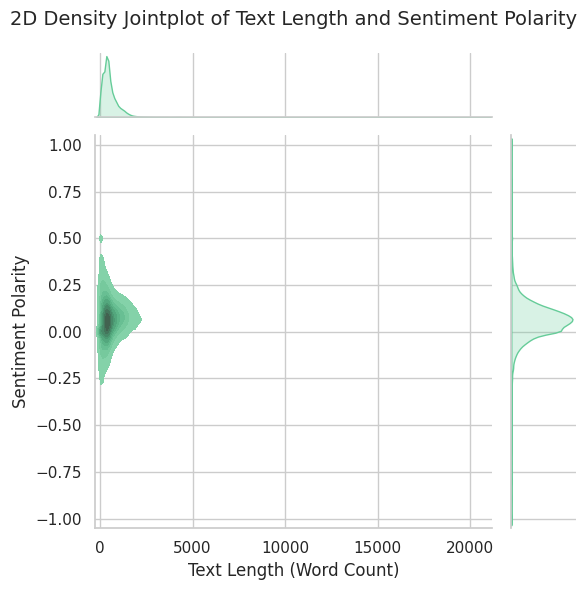

In [ ]:
plt.figure(figsize=(10, 8))
g = sns.jointplot(x='text_len', y='Polarity', kind='kde', fill=True, color='#66cc99', data=df_all)
g.plot_joint(sns.kdeplot, fill=True, color='#66cc99', zorder=0, levels=6)
plt.suptitle('2D Density Jointplot of Text Length and Sentiment Polarity', size=14)
plt.xlabel('Text Length (Word Count)')
plt.ylabel('Sentiment Polarity')
plt.tight_layout()
plt.show()


## Baseline

Train-Test

In [ ]:
from sklearn.model_selection import train_test_split

X = df_all['clean_text']
y = df_all['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 50951
Test size: 12738


Baseline Pipeline (TF-IDF + Logistic Regression)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=300))
])

baseline_model.fit(X_train, y_train)


Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('clf', LogisticRegression(max_iter=300))])

Accuracy + Classification

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Baseline Accuracy: 0.9279321714554876

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.93      6300
           1       0.93      0.92      0.93      6438

    accuracy                           0.93     12738
   macro avg       0.93      0.93      0.93     12738
weighted avg       0.93      0.93      0.93     12738



Confusion Matrix

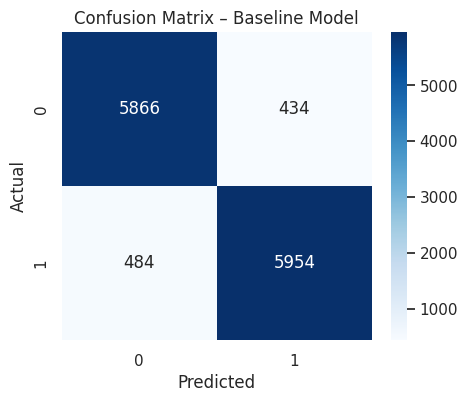

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – Baseline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


HPO

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Tam train boyutu
print("Full train size:", len(X_train))

#  örnek boyutu
TARGET_HPO_SIZE = 20000

if len(X_train) > TARGET_HPO_SIZE:
    X_train_hpo, _, y_train_hpo, _ = train_test_split(
        X_train, y_train,
        train_size=TARGET_HPO_SIZE,
        stratify=y_train,
        random_state=42
    )
    print("HPO subset size:", len(X_train_hpo))
else:
    X_train_hpo, y_train_hpo = X_train, y_train
    print("Using full train data for HPO:", len(X_train_hpo))

param_distributions = {
    # TF-IDF
    'tfidf__ngram_range': [(1, 1), (1, 2)],   # (1,3) yok -> RAM daha rahat
    'tfidf__max_df': [0.9, 0.95, 1.0],
    'tfidf__min_df': [2, 5],
    'tfidf__max_features': [50000, 80000],


    'clf__C': [0.5, 1.0, 2.0],
    'clf__class_weight': [None, 'balanced']
}



Full train size: 50951
HPO subset size: 20000


*RandomizedSearchCV*

In [ ]:
hpo_search = RandomizedSearchCV(
    estimator=baseline_model,          # TF-IDF + LR pipeline
    param_distributions=param_distributions,
    n_iter=15,                         # 15 deneme
    scoring='f1_macro',
    cv=3,
    n_jobs=1,                          # RAM için (eski -1)
    verbose=2,
    random_state=42
)

hpo_search.fit(X_train_hpo, y_train_hpo)


Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END clf__C=2.0, clf__class_weight=None, tfidf__max_df=1.0, tfidf__max_features=80000, tfidf__min_df=2, tfidf__ngram_range=(1, 2); total time=  24.3s
[CV] END clf__C=2.0, clf__class_weight=None, tfidf__max_df=1.0, tfidf__max_features=80000, tfidf__min_df=2, tfidf__ngram_range=(1, 2); total time=  24.2s
[CV] END clf__C=2.0, clf__class_weight=None, tfidf__max_df=1.0, tfidf__max_features=80000, tfidf__min_df=2, tfidf__ngram_range=(1, 2); total time=  25.1s
[CV] END clf__C=0.5, clf__class_weight=None, tfidf__max_df=1.0, tfidf__max_features=50000, tfidf__min_df=5, tfidf__ngram_range=(1, 2); total time=  25.4s
[CV] END clf__C=0.5, clf__class_weight=None, tfidf__max_df=1.0, tfidf__max_features=50000, tfidf__min_df=5, tfidf__ngram_range=(1, 2); total time=  24.4s
[CV] END clf__C=0.5, clf__class_weight=None, tfidf__max_df=1.0, tfidf__max_features=50000, tfidf__min_df=5, tfidf__ngram_range=(1, 2); total time=  24.9s
[CV] END clf__C

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('tfidf',
                                              TfidfVectorizer(stop_words='english')),
                                             ('clf',
                                              LogisticRegression(max_iter=300))]),
                   n_iter=15, n_jobs=1,
                   param_distributions={'clf__C': [0.5, 1.0, 2.0],
                                        'clf__class_weight': [None, 'balanced'],
                                        'tfidf__max_df': [0.9, 0.95, 1.0],
                                        'tfidf__max_features': [50000, 80000],
                                        'tfidf__min_df': [2, 5],
                                        'tfidf__ngram_range': [(1, 1), (1, 2)]},
                   random_state=42, scoring='f1_macro', verbose=2)

Best Model

In [ ]:
print("Best CV macro-F1:", hpo_search.best_score_)
print("\nBest Params:")
for k, v in hpo_search.best_params_.items():
    print(f"  {k}: {v}")

best_params = hpo_search.best_params_

best_model = baseline_model.set_params(**best_params)

best_model.fit(X_train, y_train)


Best CV macro-F1: 0.9211971894066101

Best Params:
  tfidf__ngram_range: (1, 2)
  tfidf__min_df: 2
  tfidf__max_features: 80000
  tfidf__max_df: 0.95
  clf__class_weight: balanced
  clf__C: 2.0


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=80000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english')),
                ('clf',
                 LogisticRegression(C=2.0, class_weight='balanced',
                                    max_iter=300))])

Baseline vs HPO

HPO Test Accuracy: 0.9421416234887737
HPO Test Macro-F1: 0.9421402966034702

HPO Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.95      0.94      6300
           1       0.95      0.94      0.94      6438

    accuracy                           0.94     12738
   macro avg       0.94      0.94      0.94     12738
weighted avg       0.94      0.94      0.94     12738



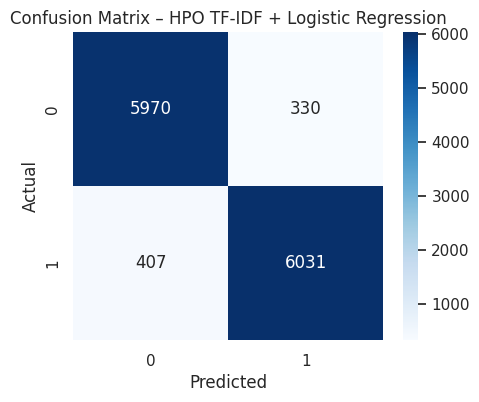

,Model,Accuracy,Macro-F1
0,Baseline TF-IDF + LR,0.927932,0.927929
1,HPO TF-IDF + LR,0.942142,0.942140


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# HPO modelinin test performansı
y_pred_hpo = best_model.predict(X_test)

hpo_acc = accuracy_score(y_test, y_pred_hpo)
hpo_f1 = f1_score(y_test, y_pred_hpo, average='macro')

print("HPO Test Accuracy:", hpo_acc)
print("HPO Test Macro-F1:", hpo_f1)
print("\nHPO Classification Report:\n", classification_report(y_test, y_pred_hpo))

cm_hpo = confusion_matrix(y_test, y_pred_hpo)

plt.figure(figsize=(5,4))
sns.heatmap(cm_hpo, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – HPO TF-IDF + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Baseline metrikleri (y_pred daha önce baseline için hesaplanmıştı)
baseline_acc = accuracy_score(y_test, y_pred)
baseline_f1 = f1_score(y_test, y_pred, average='macro')

comparison_df = pd.DataFrame({
    "Model": ["Baseline TF-IDF + LR", "HPO TF-IDF + LR"],
    "Accuracy": [baseline_acc, hpo_acc],
    "Macro-F1": [baseline_f1, hpo_f1]
})

comparison_df


Advanced Model (CharCNN)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
import string

print("Train size for CharCNN:", len(X_train))

MAX_LEN = 1000  # ilk 1000 karakter

all_text = "".join(X_train.astype(str).tolist())

allowed_chars = set(string.ascii_letters + string.digits + string.punctuation + " \n\t")

vocab_chars = sorted(set(ch for ch in all_text if ch in allowed_chars))

print("Vocab size (chars):", len(vocab_chars))
print("First 50 chars in vocab:", vocab_chars[:50])

char2idx = {ch: idx + 1 for idx, ch in enumerate(vocab_chars)}  # 0 padding için
idx2char = {idx: ch for ch, idx in char2idx.items()}

def text_to_seq(text, max_len=MAX_LEN):
    text = str(text)
    seq = [char2idx.get(ch, 0) for ch in text[:max_len]]  # bilinmeyen char → 0
    return seq

print(text_to_seq("Hello world!")[:20])


Train size for CharCNN: 50951
Vocab size (chars): 95
First 50 chars in vocab: [' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q']
[41, 70, 77, 77, 80, 1, 88, 80, 83, 77, 69, 2]


test

In [ ]:
X_train_seqs = [text_to_seq(t) for t in X_train]
X_test_seqs = [text_to_seq(t) for t in X_test]

X_train_padded = pad_sequences(X_train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_padded = np.array(X_train_padded)
X_test_padded = np.array(X_test_padded)
y_train_array = np.array(y_train)
y_test_array = np.array(y_test)

print("X_train_padded shape:", X_train_padded.shape)
print("X_test_padded shape:", X_test_padded.shape)


X_train_padded shape: (50951, 1000)
X_test_padded shape: (12738, 1000)


train

In [ ]:
from sklearn.model_selection import train_test_split

X_train_char, X_val_char, y_train_char, y_val_char = train_test_split(
    X_train_padded, y_train_array,
    test_size=0.1,
    random_state=42,
    stratify=y_train_array
)

print("Train char shape:", X_train_char.shape)
print("Val char shape:", X_val_char.shape)


Train char shape: (45855, 1000)
Val char shape: (5096, 1000)


CharCNN Model

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

vocab_size = len(vocab_chars) + 1

embedding_dim = 32
num_filters = 128

inputs = layers.Input(shape=(MAX_LEN,), dtype="int32")

x = layers.Embedding(input_dim=vocab_size,
                     output_dim=embedding_dim,
                     input_length=MAX_LEN)(inputs)

x = layers.Conv1D(filters=num_filters, kernel_size=5, activation='relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.Conv1D(filters=num_filters, kernel_size=5, activation='relu')(x)
x = layers.MaxPooling1D(pool_size=2)(x)

x = layers.GlobalMaxPooling1D()(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation='sigmoid')(x)

charcnn_model = models.Model(inputs=inputs, outputs=outputs)

charcnn_model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

charcnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 1000, 32)       │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 996, 128)       │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 498, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 494, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 247, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,049 (445.50 KB)

 Trainable params: 114,049 (445.50 KB)

 Non-trainable params: 0 (0.00 B)

Model Train

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

batch_size = 128
epochs = 8

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = charcnn_model.fit(
    X_train_char, y_train_char,
    validation_data=(X_val_char, y_val_char),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/8
359/359 - 21s - 59ms/step - accuracy: 0.8640 - loss: 0.2897 - val_accuracy: 0.9333 - val_loss: 0.1572
Epoch 2/8
359/359 - 12s - 33ms/step - accuracy: 0.9500 - loss: 0.1266 - val_accuracy: 0.9653 - val_loss: 0.0815
Epoch 3/8
359/359 - 12s - 34ms/step - accuracy: 0.9713 - loss: 0.0759 - val_accuracy: 0.9739 - val_loss: 0.0627
Epoch 4/8
359/359 - 12s - 34ms/step - accuracy: 0.9790 - loss: 0.0552 - val_accuracy: 0.9772 - val_loss: 0.0573
Epoch 5/8
359/359 - 12s - 34ms/step - accuracy: 0.9856 - loss: 0.0422 - val_accuracy: 0.9719 - val_loss: 0.0665
Epoch 6/8
359/359 - 12s - 34ms/step - accuracy: 0.9887 - loss: 0.0321 - val_accuracy: 0.9766 - val_loss: 0.0595


399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
CharCNN Test Accuracy: 0.9744857905479667
CharCNN Test Macro-F1: 0.974477827484318

CharCNN Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97      6300
           1       0.97      0.98      0.97      6438

    accuracy                           0.97     12738
   macro avg       0.97      0.97      0.97     12738
weighted avg       0.97      0.97      0.97     12738



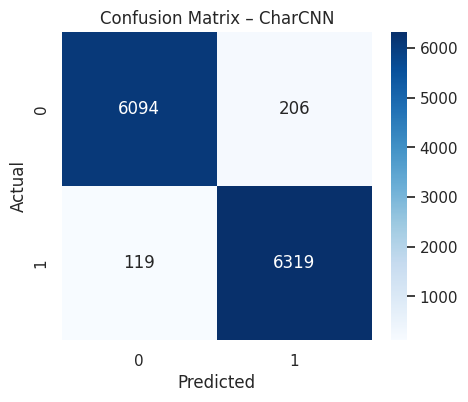

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Olasılık tahminleri
y_pred_char_proba = charcnn_model.predict(X_test_padded)
y_pred_char = (y_pred_char_proba >= 0.5).astype(int).ravel()

char_acc = accuracy_score(y_test_array, y_pred_char)
char_f1 = f1_score(y_test_array, y_pred_char, average='macro')

print("CharCNN Test Accuracy:", char_acc)
print("CharCNN Test Macro-F1:", char_f1)
print("\nCharCNN Classification Report:\n", classification_report(y_test_array, y_pred_char))

cm_char = confusion_matrix(y_test_array, y_pred_char)

plt.figure(figsize=(5,4))
sns.heatmap(cm_char, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix – CharCNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


All Models

In [ ]:
import pandas as pd

comparison_all = pd.DataFrame({
    "Model": [
        "Baseline TF-IDF + LR",
        "HPO TF-IDF + LR",
        "CharCNN (character-level)"
    ],
    "Accuracy": [
        baseline_acc,
        hpo_acc,
        char_acc
    ],
    "Macro-F1": [
        baseline_f1,
        hpo_f1,
        char_f1
    ]
})

comparison_all


,Model,Accuracy,Macro-F1
0,Baseline TF-IDF + LR,0.927932,0.927929
1,HPO TF-IDF + LR,0.942142,0.942140
2,CharCNN (character-level),0.974486,0.974478


Error Analysis

In [ ]:
import pandas as pd

error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "pred_baseline": y_pred,
    "pred_hpo": y_pred_hpo
})

error_df.head()


,text,true_label,pred_baseline,pred_hpo
0,Hong Kong leader says she won't blindly obey B...,1,1,1
1,It’s Children Against Federal Lawyers in Immig...,0,1,0
2,The FBI's Clinton Investigation Is Wider Than ...,1,1,1
3,Republicans could lose U.S. House in 2018 over...,1,1,1
4,Our Grandmothers Know Best – Traditional Remed...,1,1,1


In [ ]:
# Error flags
error_df["baseline_error"] = error_df["true_label"] != error_df["pred_baseline"]
error_df["hpo_error"] = error_df["true_label"] != error_df["pred_hpo"]

# Error direction function
def error_type(true, pred):
    if true == 0 and pred == 1:
        return "Fake→Real"
    elif true == 1 and pred == 0:
        return "Real→Fake"
    else:
        return "Correct"

error_df["baseline_error_type"] = error_df.apply(
    lambda r: error_type(r.true_label, r.pred_baseline), axis=1
)

error_df["hpo_error_type"] = error_df.apply(
    lambda r: error_type(r.true_label, r.pred_hpo), axis=1
)

# Summary tables
baseline_error_summary = error_df["baseline_error_type"].value_counts()
hpo_error_summary = error_df["hpo_error_type"].value_counts()

baseline_error_summary, hpo_error_summary


(baseline_error_type
 Correct      11820
 Real→Fake      484
 Fake→Real      434
 Name: count, dtype: int64,
 hpo_error_type
 Correct      12001
 Real→Fake      407
 Fake→Real      330
 Name: count, dtype: int64)

In [ ]:
# Add word count from main dataframe
error_df["word_count"] = df_all.loc[X_test.index, "word_count"].values

# Create length slices
error_df["length_slice"] = pd.qcut(
    error_df["word_count"],
    q=3,
    labels=["Short", "Medium", "Long"]
)

# Error rates by slice
length_slice_errors = (
    error_df
    .groupby("length_slice")[["baseline_error", "hpo_error"]]
    .mean()
    .reset_index()
)

length_slice_errors


/tmp/ipython-input-2769841970.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("length_slice")[["baseline_error", "hpo_error"]]


,length_slice,baseline_error,hpo_error
0,Short,0.064281,0.054156
1,Medium,0.069006,0.053462
2,Long,0.082921,0.065960


SLICE-BASED ANALYSIS – METİN UZUNLUĞU

In [ ]:
# Add word count from main dataframe
error_df["word_count"] = df_all.loc[X_test.index, "word_count"].values

# Create length slices
error_df["length_slice"] = pd.qcut(
    error_df["word_count"],
    q=3,
    labels=["Short", "Medium", "Long"]
)

# Error rates by slice
length_slice_errors = (
    error_df
    .groupby("length_slice")[["baseline_error", "hpo_error"]]
    .mean()
    .reset_index()
)

length_slice_errors


/tmp/ipython-input-2769841970.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("length_slice")[["baseline_error", "hpo_error"]]


,length_slice,baseline_error,hpo_error
0,Short,0.064281,0.054156
1,Medium,0.069006,0.053462
2,Long,0.082921,0.065960


SLICE-BASED ANALYSIS – DATASET (ISOT vs WELFake)

In [ ]:
# Add dataset source
error_df["source_dataset"] = df_all.loc[X_test.index, "source_dataset"].values

# Error rates by dataset
dataset_slice_errors = (
    error_df
    .groupby("source_dataset")[["baseline_error", "hpo_error"]]
    .mean()
    .reset_index()
)

dataset_slice_errors


,source_dataset,baseline_error,hpo_error
0,ISOT,0.030578,0.024618
1,WELFake,0.135857,0.108964



CASE STUDY – HPO MODEL


In [ ]:
# Random misclassified samples from HPO
hard_cases = error_df[error_df["hpo_error"]].sample(5, random_state=42)

for _, row in hard_cases.iterrows():
    print("True label:", row.true_label,
          "Predicted:", row.pred_hpo)
    print(row.text[:500])
    print("-" * 80)


True label: 0 Predicted: 1
Exodus from Puerto Rico could upend Florida vote in 2016 presidential race Puerto Rico’s economic crisis meant Jeffrey Rondon, 25, struggled to find even part-time work, so he recently joined the growing exodus from his Caribbean island to Florida. Now he holds a full-time restaurant job and something that could upend the 2016 presidential election — the right to vote in Florida, the biggest of all swing states. “It’s important to vote and be heard — it’s a privilege,” said Rondon, who is one of
--------------------------------------------------------------------------------
True label: 1 Predicted: 0
How Donald Trump is already indirectly helping Russia and Syria How Donald Trump is already indirectly helping Russia and Syria November 11, 2016 - Fort Russ - Ruslan Ostashko, PolitRussia - translated by J. Arnoldski - Perhaps the most famous media project of Donald Trump is the reality show “The Apprentice” on NBC, in which Trump played himself and subjected p